# 12 · Queueing theory

Waiting lines are the purest application of the processes so far: Poisson arrivals, exponential or general
services, birth-death chains. This notebook derives the classical results - M/M/1, Erlang's B and C formulas,
M/M/c/K, the Pollaczek-Khinchine formula for general service times, Little's law - checks them by simulation,
and turns them into decisions: how many agents a call centre needs, and why variability costs as much as load.

**What you will learn**
- compute M/M/1, M/M/c, M/M/c/K and M/G/1 performance measures
- use Little's law as a modelling and checking tool
- staff a multi-server system for a service-level target
- judge when exponential assumptions are adequate

**Before you start:** notebooks 09-11  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import queues as qu, output as oa, models, datasets
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## M/M/1 and the price of high utilisation

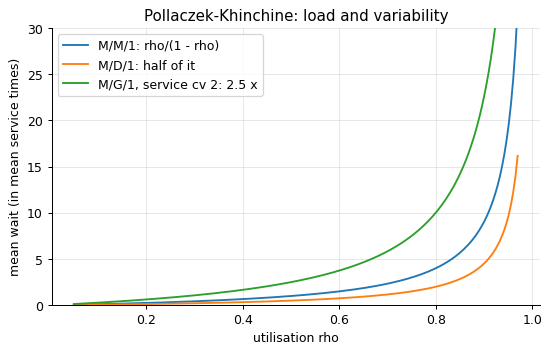

M/M/1 at rho = 0.9 by the Lindley recursion: Wq = 10.08 +- 0.64 (theory 9)


In [2]:
rho = np.linspace(0.05, 0.97, 200)
plt.plot(rho, [qu.mm1(r, 1.0)["Wq"] for r in rho], label="M/M/1: rho/(1 - rho)")
plt.plot(rho, [qu.mg1(r, 1.0, 1.0)["Wq"] for r in rho], label="M/D/1: half of it")
plt.plot(rho, [qu.mg1(r, 1.0, 1 + 4.0)["Wq"] for r in rho], label="M/G/1, service cv 2: 2.5 x")
plt.ylim(0, 30); plt.xlabel("utilisation rho"); plt.ylabel("mean wait (in mean service times)"); plt.legend(); plt.title("Pollaczek-Khinchine: load and variability"); plt.show()
n = 300_000
w = qu.lindley(R(1).exponential(1 / 0.9, n), R(2).exponential(1.0, n))
bm_ = oa.batch_means(w[20_000:], 20)
print(f"M/M/1 at rho = 0.9 by the Lindley recursion: Wq = {bm_['estimate']:.2f} +- {bm_['std_error']:.2f} (theory {qu.mm1(0.9, 1.0)['Wq']:.0f})")

The mean wait in M/G/1 is ρ E[S](1 + c_s²) / (2(1 − ρ)): it explodes as the utilisation approaches one, and it
scales with (1 + c_s²)/2, so halving the variability of service times is worth as much as a big drop in load.
Even 300 000 simulated customers give only about ±7 % accuracy at ρ = 0.9 - waits are strongly
autocorrelated (notebook 14).

## Many servers: Erlang B and C

In [3]:
a = 20.0
rows = []
for c in (21, 22, 24, 26, 30):
    m = qu.mmc(a, 1.0, c)
    rows.append((c, a / c, qu.erlang_b(c, a), m["P_wait"], m["Wq"], qu.service_level(a, 1.0, c, 0.1)))
print("offered load 20 erlangs")
print(pd.DataFrame(rows, columns=["servers", "utilisation", "Erlang B (blocked)", "Erlang C P(wait)", "Wq", "P(wait <= 0.1)"]).to_string(index=False, float_format="%.4f"))
arr = np.cumsum(R(3).exponential(1 / 20.0, 400_000))
sim = qu.simulate_ggc(arr, R(4).exponential(1.0, 400_000), 22)
print(f"\nsimulated M/M/22: Wq {sim['wait'][20000:].mean():.4f}, P(wait > 0) {np.mean(sim['wait'][20000:] > 0):.4f}")

offered load 20 erlangs
 servers  utilisation  Erlang B (blocked)  Erlang C P(wait)     Wq  P(wait <= 0.1)
      21       0.9524              0.1314            0.7606 0.7606          0.3117
      22       0.9091              0.1067            0.5679 0.2840          0.5350
      24       0.8333              0.0661            0.2981 0.0745          0.8002
      26       0.7692              0.0372            0.1434 0.0239          0.9213
      30       0.6667              0.0085            0.0250 0.0025          0.9908



simulated M/M/22: Wq 0.2885, P(wait > 0) 0.5635


Erlang B gives the fraction of calls lost when there is no waiting room (telephone trunks, hospital beds
without a queue); Erlang C the probability of waiting when there is one. The computation uses the stable
recursion B(k) = aB(k − 1)/(k + aB(k − 1)) - factorials of hundreds of servers never appear.

## Economies of scale and square-root staffing

In [4]:
rows = []
for lam in (10, 100, 1000, 10_000):
    s = qu.staffing(lam, 1 / 4, 0.8, 20 / 60)                         # 4-min calls, 80 % answered within 20 s
    rows.append((lam, s["offered_load"], s["c"], s["offered_load"] / s["c"], s["beta"]))
print(pd.DataFrame(rows, columns=["calls / min", "offered load", "agents needed", "utilisation", "beta = (c - a)/sqrt(a)"]).to_string(index=False, float_format="%.3f"))

 calls / min  offered load  agents needed  utilisation  beta = (c - a)/sqrt(a)
          10        40.000             46        0.870                   0.949
         100       400.000            411        0.973                   0.550
        1000      4000.000           4016        0.996                   0.253
       10000     40000.000          40018        1.000                   0.090


Pooling is powerful: a small centre needs agents idle a third of the time to meet the service level, a large
one runs at 99 % utilisation. The safety staffing grows like √a (Halfin-Whitt) or slower - for a fixed answer
time the β needed even falls with the load. Splitting a large pool into independent small ones throws this
away.

## Little's law and finite capacity

In [5]:
m = qu.mmck(12.0, 1.0, 10, 15)
print(f"M/M/10/15 at 12 arrivals per unit time: blocking {m['P_block']:.4f}, throughput {m['throughput']:.3f}, L = {m['L']:.3f}, W = {m['W']:.3f}; L / (lambda_eff W) = {m['L'] / (m['throughput'] * m['W']):.6f}")
bd = models.mmck_chain(12.0, 1.0, 10, 15)
print("same law from the birth-death generator:", np.max(np.abs(bd["chain"].stationary() - m["p"])))
grid = np.linspace(arr[20_000], arr[200_000], 100_001)
Lsim = qu.number_in_system(arr[:220_000], sim["depart"][:220_000], grid).mean()
inside = (arr >= grid[0]) & (arr <= grid[-1])
lam_obs, W_obs = inside.sum() / (grid[-1] - grid[0]), np.mean((sim["depart"] - arr)[inside])
print(f"simulated M/M/22: time-average L = {Lsim:.3f}; observed lambda x observed W = {lam_obs * W_obs:.3f}")

M/M/10/15 at 12 arrivals per unit time: blocking 0.2033, throughput 9.561, L = 12.011, W = 1.256; L / (lambda_eff W) = 1.000000
same law from the birth-death generator: 2.7755575615628914e-17
simulated M/M/22: time-average L = 25.300; observed lambda x observed W = 25.296


L = λW holds for any stable system in which customers are conserved, with no distributional assumptions; with
blocking, λ must be the rate of *admitted* customers. It converts a time average (L) into a customer average
(W) and is the most useful consistency check of any queueing simulation.

## Real service times: the call centre's handle times

In [6]:
cc = pd.read_csv(datasets.path("call_centre.csv"), comment="#")
h = cc.handle_min[cc.handle_min > 0].to_numpy()
cs2 = h.var() / h.mean() ** 2
print(f"handle times: mean {h.mean():.2f} min, cv {np.sqrt(cs2):.2f}, {np.sum(cc.handle_min == 0)} zero-length records removed")
lam = 150 / 60
for c in (11, 12, 13):
    wq_m = qu.mmc(lam, 1 / h.mean(), c)["Wq"] * 60
    wq_ac = qu.allen_cunneen(lam, h.mean(), c, 1.0, cs2) * 60
    arr = np.cumsum(R(5).exponential(1 / lam, 200_000))
    sim = qu.simulate_ggc(arr, R(6).choice(h, 200_000), c)["wait"][10_000:].mean() * 60
    print(f"{c} agents at 150 calls/h: Wq exponential model {wq_m:5.1f} s, Allen-Cunneen {wq_ac:5.1f} s, simulation with the measured handle times {sim:5.1f} s")

handle times: mean 3.96 min, cv 0.79, 82 zero-length records removed


11 agents at 150 calls/h: Wq exponential model 141.7 s, Allen-Cunneen 114.6 s, simulation with the measured handle times 120.3 s


12 agents at 150 calls/h: Wq exponential model  48.6 s, Allen-Cunneen  39.3 s, simulation with the measured handle times  40.4 s


13 agents at 150 calls/h: Wq exponential model  20.8 s, Allen-Cunneen  16.8 s, simulation with the measured handle times  17.4 s


The measured handle times are lognormal with cv ≈ 0.8, less variable than the exponential that Erlang C
assumes, so Erlang C overstates the waits - here by about 15-20 %. The Allen-Cunneen correction (multiply by
(c_a² + c_s²)/2) is close; resampling the real handle times in a simulation is the reference. Which model to
trust is settled in the project, where the arrival rate also varies through the day.

## Inside the algorithm: Erlang B by recursion and why not by factorials

In [7]:
a, c = 380.0, 400
b = 1.0
for k in range(1, c + 1):
    b = a * b / (k + a * b)
try:
    direct = a**c / math.factorial(c) / sum(a**k / math.factorial(k) for k in range(c + 1))
except OverflowError as e:
    direct = f"OverflowError ({e})"
print(f"recursion {b:.6e}; library {qu.erlang_b(c, a):.6e}; direct formula: {direct}")

recursion 1.393158e-02; library 1.393158e-02; direct formula: OverflowError ((34, 'Numerical result out of range'))


## Exercises
1. A hospital ward has 30 beds, admissions are Poisson at 5 per day, stays average 5 days. Compute the probability that an admission is turned away (Erlang B) and the number of beds needed for 1 % blocking. Check one answer by simulating M/G/c/c with lognormal stays (insensitivity).
2. Two call centres each receive 100 calls/h with 4-min calls and must answer 80 % in 20 s. Compare the agents needed separately and when pooled, and simulate the pooled centre with the measured handle times.
3. **Implement it yourself:** write the Lindley recursion and an estimate of P(W > t) for M/M/1, and compare with the exact rho e^{-(mu - lambda) t}.